In [1]:
options(repos = c(CRAN = "https://cloud.r-project.org"))

if (!require("pacman")) install.packages("pacman")
pacman::p_load(tidyverse, ggplot2, dplyr, lubridate, stringr, readxl, data.table, gdata, scales, data.table)




Loading required package: pacman



In [2]:

ma.2010 <- read_csv("../data/output/data-2010.csv")
ma.2011 <- read_csv("../data/output/data-2011.csv")
ma.2012 <- read_csv("../data/output/data-2012.csv")
ma.2013 <- read_csv("../data/output/data-2013.csv")
ma.2014 <- read_csv("../data/output/data-2014.csv")
ma.2015 <- read_csv("../data/output/data-2015.csv")



Rows: 109950 Columns: 91
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (15): contractid, state, county, org_type, plan_type, partd, snp, eghp, ...
dbl (66): planid, fips, n_nonmiss, avg_enrollment, sd_enrollment, min_enroll...
lgl (10): partcd_score, risk_star5, risk_star45, risk_star4, risk_star35, ri...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 68003 Columns: 95
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (15): contractid, state, county, org_type, plan_type, partd, snp, eghp, ...
dbl (71): planid, fips, n_nonmiss, avg_enrollment, sd_enrollment, min_enroll...
lgl  (9): risk_star5, risk_star45, risk_star4, risk_star35, risk_star3, risk...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types =

In [3]:
fix_type <- function(df) {
  df$org_parent <- as.character(df$org_parent)
  df
}
ma.2011 <- fix_type(ma.2011)

Warning message:
“Unknown or uninitialised column: `org_parent`.”


ERROR: [1m[33mError[39m in `$<-`:[22m
[1m[22m[33m![39m Assigned data `as.character(df$org_parent)` must be compatible with
  existing data.
[31m✖[39m Existing data has 68003 rows.
[31m✖[39m Assigned data has 0 rows.
[36mℹ[39m Only vectors of size 1 are recycled.
[1mCaused by error in `vectbl_recycle_rhs_rows()`:[22m
[33m![39m Can't recycle input of size 0 to size 68003.


In [4]:
data.full <- bind_rows(ma.2010, ma.2011, ma.2012, ma.2013, ma.2014, ma.2015)  %>%
  mutate(market_share = avg_enrollment / avg_enrolled)

# Summarize the data 

# Question1. 
Provide a table of summary statistics showing the mean star rating, mean number of enrollments, and mean market share for plans by year. The variables (star rating, enrollments, market share) and total plans number

In [5]:
summary_table <- data.full %>%
  group_by(year) %>%
  summarise(
    'Average Star Rating' = round(mean(Star_Rating, na.rm = TRUE), 2),
    'Average Enrollments' = round(mean(avg_enrollment, na.rm = TRUE), 2),
    'Average Market Share' = round(mean(market_share, na.rm = TRUE), 4),
    'Total Number Of Plans' = n()
  )

print(summary_table)

# A tibble: 6 × 5
   year `Average Star Rating` `Average Enrollments` `Average Market Share`
  <dbl>                 <dbl>                 <dbl>                  <dbl>
1  2010                  2.97                  256.                 0.0658
2  2011                  3.26                  343.                 0.0855
3  2012                  3.36                  377.                 0.0856
4  2013                  3.55                  396.                 0.0815
5  2014                  3.81                  437.                 0.08  
6  2015                  3.96                  470.                 0.0787
# ℹ 1 more variable: `Total Number Of Plans` <int>


# Question2.
Repeat part 1 but focusing only on plans without a star rating. Naturally, in this case, you need only present the mean enrollments and market share, not the mean star rating, along with a column showing the count of all such plans in each year.



In [6]:
without_rating_table <- data.full %>%
  filter(is.na(Star_Rating)) %>%
  group_by(year) %>%
  summarise(
    'Average Enrollments' = round(mean(avg_enrollment, na.rm = TRUE), 2),
    'Average Market Share' = round(mean(market_share, na.rm = TRUE), 4),
    'Total Number Of Plans' = n()
  )

print(without_rating_table)

# A tibble: 6 × 4
   year `Average Enrollments` `Average Market Share` `Total Number Of Plans`
  <dbl>                 <dbl>                  <dbl>                   <int>
1  2010                  107.                 0.0672                   49431
2  2011                  168.                 0.09                     12754
3  2012                  173.                 0.0567                    9077
4  2013                  214.                 0.06                      3661
5  2014                  258.                 0.0557                    3708
6  2015                  314.                 0.0405                    4680


# Question3.
Provide bar graphs showing the distribution of star ratings in 2010, 2012, and 2015. How has this distribution changed over time?

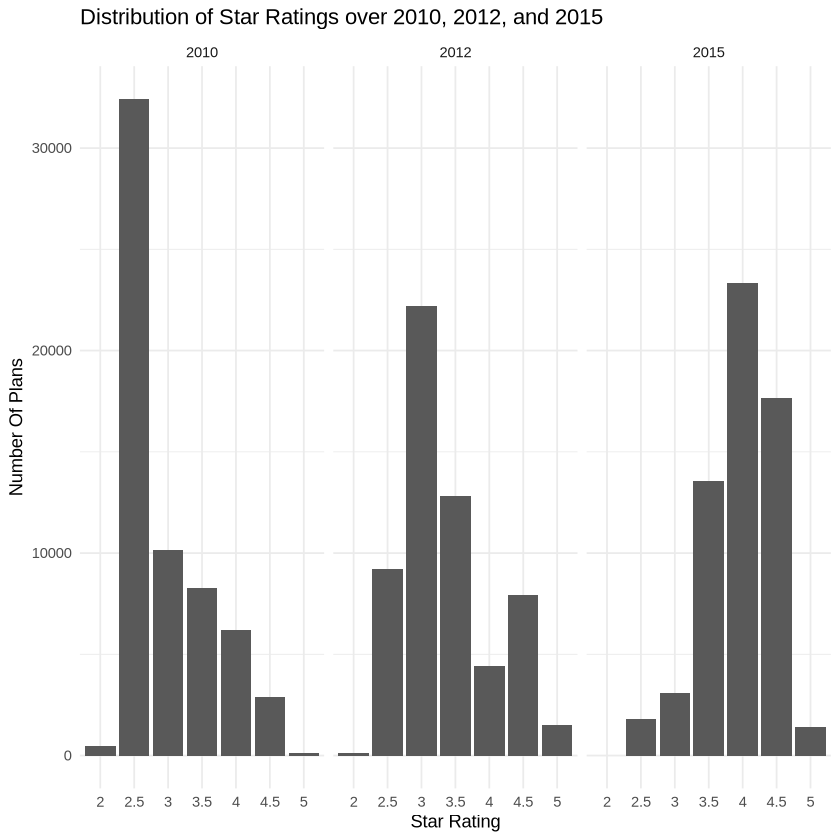

In [7]:
data.full %>%
  filter(year %in% c(2010, 2012, 2015), !is.na(Star_Rating)) %>%
  mutate(year = as.factor(year)) %>%
  ggplot(aes(x = as.factor(Star_Rating))) +
  geom_bar() +
  facet_wrap(~ year) +
  labs(
    title = "Distribution of Star Ratings over 2010, 2012, and 2015",
    x = "Star Rating",
    y = "Number Of Plans"
  ) +
  theme_minimal()

In 2010, we observed a significant decline in the number of highly rated plans. By 2012, the difference was not as pronounced, and in 2015, there was a noticeable improvement, with an increase in the availability of high-rated plans.

# Question4. 
Provide a table showing the regression resuls from an ordinary least squares regression of market share on star ratings, again for each year from 2010 through 2015. In this table, the rows should reflect your coefficient estimates and the columns should reflect different estimates for each year. In your regression specifications, please treat star ratings of 2.5 or below as your excluded category, and include indicator variables for star ratings of 3, 3.5, 4, and 4.5 or above.

In [8]:
data.full <- data.full %>%
  mutate(
    star_3   = as.integer(Star_Rating == 3),
    star_35  = as.integer(Star_Rating == 3.5),
    star_4   = as.integer(Star_Rating == 4),
    star_45  = as.integer(Star_Rating >= 4.5)
  )

estimate <- list()

for(yr in 2010:2015){
  ols <- lm(market_share ~ star_3 + star_35 + star_4 + star_45, 
            data = data.full %>% filter(year == yr, !is.na(Star_Rating), !is.na(market_share)))
  estimate[[as.character(yr)]] <- coef(ols)
}

ols_table <- as.data.frame(estimate)
colnames(ols_table) <- c("2010", "2011", "2012", "2013", "2014", "2015")
rownames(ols_table) <- c("Excluded (<= 2.5 stars)", "3 Stars", "3.5 Stars", "4 Stars", ">= 4.5 Stars")

print(round(ols_table, 4))

                           2010    2011    2012   2013   2014   2015
Excluded (<= 2.5 stars)  0.0633  0.0702  0.0789 0.0491 0.0640 0.0606
3 Stars                  0.0128  0.0350  0.0307 0.0621 0.0267 0.0271
3.5 Stars                0.0006  0.0191  0.0129 0.0385 0.0273 0.0388
4 Stars                 -0.0031  0.0028 -0.0246 0.0172 0.0074 0.0115
>= 4.5 Stars            -0.0075 -0.0095 -0.0134 0.0222 0.0071 0.0233


# Estimate ATEs

# Question5.
Calculate the running variable underlying the star rating. Provide a table showing the number of plans that are rounded up into a 3-star, 3.5-star, 4-star, 4.5-star, and 5-star rating.

In [9]:
quality_vars <- c(
  "breastcancer_screen",
  "rectalcancer_screen",
  "cv_diab_cholscreen",
  "glaucoma_test",
  "monitoring",
  "flu_vaccine",
  "pn_vaccine",
  "physical_health",
  "mental_health",
  "osteo_test",
  "physical_monitor",
  "primaryaccess",
  "osteo_manage",
  "diab_healthy",
  "bloodpressure",
  "ra_manage",
  "copd_test",
  "bladder",
  "falling",
  "nodelays",
  "doctor_communicate",
  "carequickly",
  "customer_service",
  "overallrating_care",
  "overallrating_plan",
  "complaints_plan",
  "appeals_timely",
  "appeals_review",
  "leave_plan",
  "audit_problems",
  "hold_times",
  "info_accuracy",
  "ttyt_available"
)

library(dplyr)

ma.2010 <- ma.2010 %>%
  rowwise() %>%
  mutate(
    raw_rating = mean(c_across(all_of(quality_vars)), na.rm = TRUE)
  ) %>%
  ungroup()

In [10]:
round_up_counts <- ma.2010 %>%
  filter(!is.na(raw_rating)) %>%
  filter(!is.na(partc_score)) %>%
  mutate(
    round_ups = case_when(
      raw_rating >= 2.75 & partc_score == 3.0  ~ "Rounded up to 3",
      raw_rating >= 3.25 & partc_score == 3.5  ~ "Rounded up to 3.5",
      raw_rating >= 3.75 & partc_score == 4.0  ~ "Rounded up to 4",
      raw_rating >= 4.25 & partc_score == 4.5  ~ "Rounded up to 4.5",
      raw_rating >= 4.75 & partc_score == 5.0  ~ "Rounded up to 5",
      TRUE ~ NA_character_
    )
  ) %>%
  filter(!is.na(round_ups)) %>%
  count(round_ups) %>%
  rename('Star Rating' = round_ups, 'Corresponding Number Of Plans' = n)
print(round_up_counts)

# A tibble: 5 × 2
  `Star Rating`     `Corresponding Number Of Plans`
  <chr>                                       <int>
1 Rounded up to 3                             10162
2 Rounded up to 3.5                            8262
3 Rounded up to 4                              4320
4 Rounded up to 4.5                             773
5 Rounded up to 5                                30


# Question6. 
Using the RD estimator with a bandwidth of 0.125, provide an estimate of the effect of receiving a 3-star versus a 2.5 star rating on enrollments. Repeat the exercise to estimate the effects at 3.5 stars, and summarize your results in a table.

In [11]:
ma_25star_candidates <- ma.2010 %>%
  filter(
    !is.na(raw_rating),
    !is.na(partc_score),
    Star_Rating %in% c(2.5, 3)
  )

n_candidates_total <- nrow(ma_25star_candidates)
n_candidates_by_score <- ma_25star_candidates %>% count(partc_score)

ma_25star <- ma_25star_candidates %>%
  filter(
    raw_rating >= 2.5,
    raw_rating <= 3,
    (raw_rating >= 2.75 & Star_Rating == 3) | (raw_rating < 2.75 & Star_Rating == 2.5)
  )

ma.rd1 <- ma_25star %>%
  mutate(market_share = avg_enrollment / avg_enrolled,
         score = raw_rating - 2.75,
         treat = (score>=0),
         window = (score>=-.125 & score<=.125),
         score_treat=score*treat)

library(rdrobust)

star25.1 <- lm(market_share ~ score + treat + score_treat, data= (ma.rd1 %>% filter(window==TRUE)))
est1 <- as.numeric(star25.1$coef[3])

In [12]:
ma_25star_candidates <- ma.2010 %>%
  filter(
    !is.na(raw_rating),
    !is.na(partc_score),
    Star_Rating %in% c(3, 3.5)
  )

n_candidates_total <- nrow(ma_25star_candidates)
n_candidates_by_score <- ma_25star_candidates %>% count(partc_score)

ma_25star <- ma_25star_candidates %>%
  filter(
    raw_rating >= 3,
    raw_rating <= 3.5,
    (raw_rating >= 3.25 & Star_Rating == 3.5) | (raw_rating < 3.25 & Star_Rating == 3)
  )

ma.rd2 <- ma_25star %>%
  mutate(market_share = avg_enrollment / avg_enrolled,
         score = raw_rating - 3.25,
         treat = (score>=0),
         window = (score>=-.125 & score<=.125),
         score_treat=score*treat)

library(rdrobust)

star25.2 <- lm(market_share ~ score + treat + score_treat, data= (ma.rd2 %>% filter(window==TRUE)))
est2 <- as.numeric(star25.2$coef[3])

In [13]:
# our two estimates
est1 <- as.numeric(star25.1$coef[3])
est2 <- as.numeric(star25.2$coef[3])

comparison_table <- data.frame(row.names = c("RD Estimate"), `3 vs 3.5` = est1, `2.5 vs 3` = est2 )

print(comparison_table)

             X3.vs.3.5   X2.5.vs.3
RD Estimate 0.05488423 -0.03946457


# Question7.
Repeat your results for bandwidhts of 0.1, 0.12, 0.13, 0.14, and 0.15 (again for 3 and 3.5 stars). Show all of the results in a graph. How sensitive are your findings to the choice of bandwidth?

In [14]:
ma_25star_candidates <- ma.2010 %>%
  filter(
    !is.na(raw_rating),
    !is.na(partc_score),
    Star_Rating %in% c(2.5, 3)
  )

n_candidates_total <- nrow(ma_25star_candidates)
n_candidates_by_score <- ma_25star_candidates %>% count(partc_score)

ma_25star <- ma_25star_candidates %>%
  filter(
    raw_rating >= 2.5,
    raw_rating <= 3,
    (raw_rating >= 2.75 & Star_Rating == 3) | (raw_rating < 2.75 & Star_Rating == 2.5)
  )

ma.rd1 <- ma_25star %>%
  mutate(market_share = avg_enrollment / avg_enrolled,
         score = raw_rating - 2.75,
         treat = (score>=0),
         window1 = (score>=-.1 & score<=.1),
         window2 = (score>=-.12 & score<=.12),
         window3 = (score>=-.13 & score<=.13),
         window4 = (score>=-.14 & score<=.14),
         window5 = (score>=-.15 & score<=.15),
         score_treat=score*treat)

library(rdrobust)

star25.1 <- lm(market_share ~ score + treat + score_treat, data= (ma.rd1 %>% filter(window1==TRUE)))
star25.2 <- lm(market_share ~ score + treat + score_treat, data= (ma.rd1 %>% filter(window2==TRUE)))
star25.3 <- lm(market_share ~ score + treat + score_treat, data= (ma.rd1 %>% filter(window3==TRUE)))
star25.4 <- lm(market_share ~ score + treat + score_treat, data= (ma.rd1 %>% filter(window4==TRUE)))
star25.5 <- lm(market_share ~ score + treat + score_treat, data= (ma.rd1 %>% filter(window5==TRUE)))
est1 <- as.numeric(star25.1$coef[3])
est2 <- as.numeric(star25.2$coef[3])
est3 <- as.numeric(star25.3$coef[3])
est4 <- as.numeric(star25.4$coef[3])
est5 <- as.numeric(star25.5$coef[3])

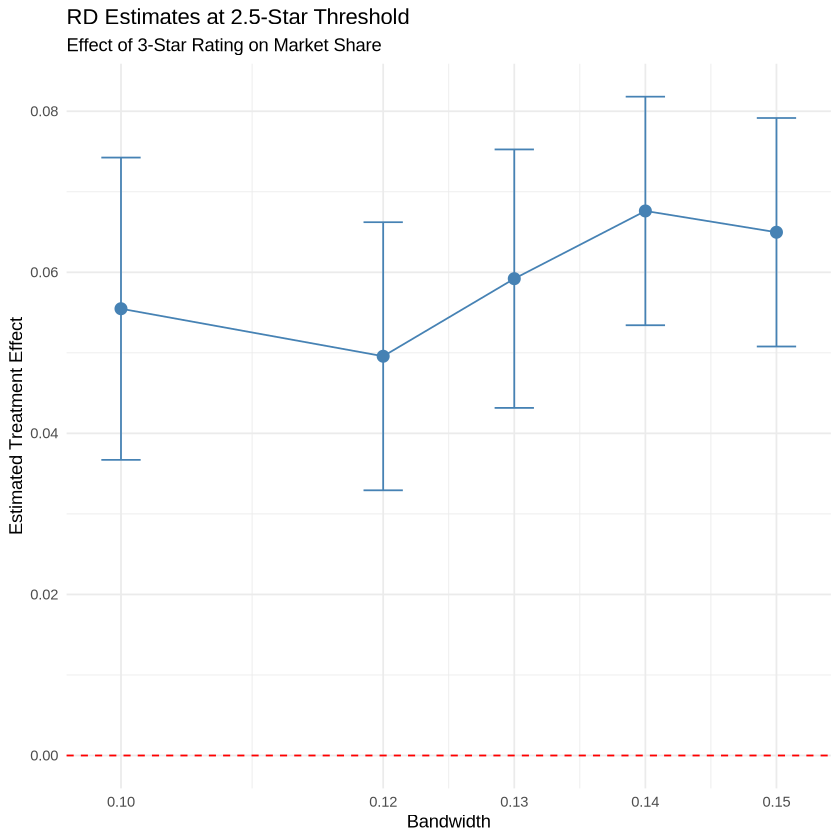

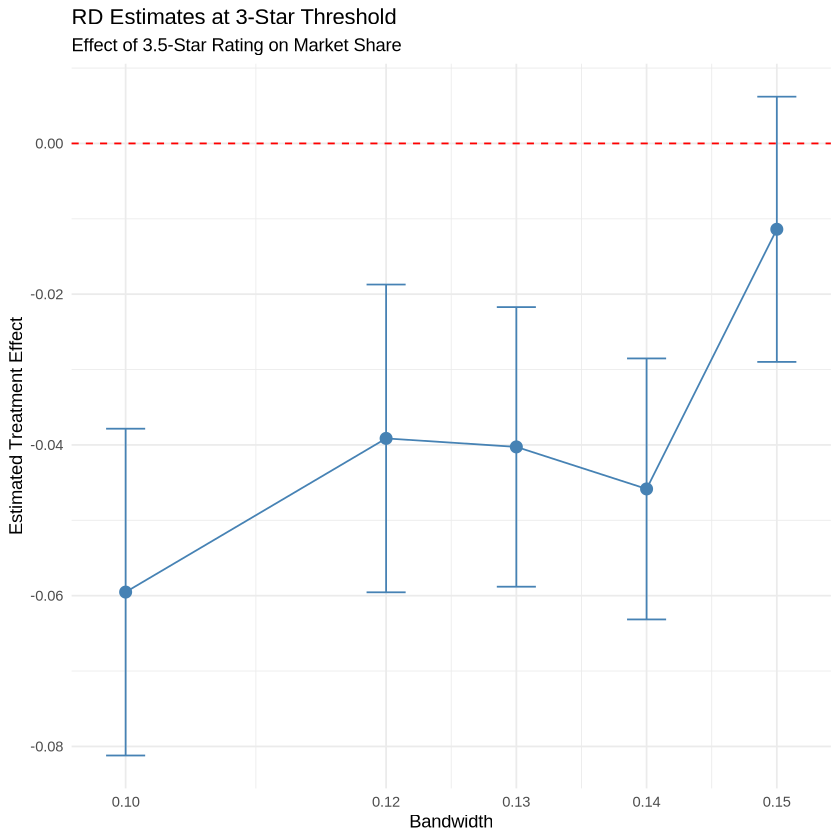

In [15]:
library(ggplot2)
library(ggplot2)
library(rdrobust)

# Create a dataframe of estimates and bandwidths
rd_results <- data.frame(
  bandwidth = c(0.10, 0.12, 0.13, 0.14, 0.15),
  estimate  = c(est1, est2, est3, est4, est5)
)

# Add confidence intervals
se_list <- c(
  summary(star25.1)$coef[3, 2],
  summary(star25.2)$coef[3, 2],
  summary(star25.3)$coef[3, 2],
  summary(star25.4)$coef[3, 2],
  summary(star25.5)$coef[3, 2]
)

rd_results <- rd_results %>%
  mutate(
    se    = se_list,
    ci_lo = estimate - 1.96 * se,
    ci_hi = estimate + 1.96 * se
  )

# Plot
ggplot(rd_results, aes(x = bandwidth, y = estimate)) +
  geom_point(size = 3, color = "steelblue") +
  geom_line(color = "steelblue") +
  geom_errorbar(aes(ymin = ci_lo, ymax = ci_hi), width = 0.003, color = "steelblue") +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red") +
  scale_x_continuous(breaks = rd_results$bandwidth) +
  labs(
    title    = "RD Estimates at 2.5-Star Threshold",
    subtitle = "Effect of 3-Star Rating on Market Share",
    x        = "Bandwidth",
    y        = "Estimated Treatment Effect"
  ) +
  theme_minimal()
ma_25star_candidates <- ma.2010 %>%
  filter(
    !is.na(raw_rating),
    !is.na(partc_score),
    Star_Rating %in% c(3, 3.5)
  )

n_candidates_total <- nrow(ma_25star_candidates)
n_candidates_by_score <- ma_25star_candidates %>% count(partc_score)

ma_25star <- ma_25star_candidates %>%
  filter(
    raw_rating >= 3,
    raw_rating <= 3.5,
    (raw_rating >= 3.25 & Star_Rating == 3.5) | (raw_rating < 3.25 & Star_Rating == 3)
  )

ma.rd2 <- ma_25star %>%
  mutate(market_share = avg_enrollment / avg_enrolled,
         score = raw_rating - 3.25,
         treat = (score>=0),
         window1 = (score>=-.1 & score<=.1),
         window2 = (score>=-.12 & score<=.12),
         window3 = (score>=-.13 & score<=.13),
         window4 = (score>=-.14 & score<=.14),
         window5 = (score>=-.15 & score<=.15),
         score_treat=score*treat)

star25.1 <- lm(market_share ~ score + treat + score_treat, data= (ma.rd2 %>% filter(window1==TRUE)))
star25.2 <- lm(market_share ~ score + treat + score_treat, data= (ma.rd2 %>% filter(window2==TRUE)))
star25.3 <- lm(market_share ~ score + treat + score_treat, data= (ma.rd2 %>% filter(window3==TRUE)))
star25.4 <- lm(market_share ~ score + treat + score_treat, data= (ma.rd2 %>% filter(window4==TRUE)))
star25.5 <- lm(market_share ~ score + treat + score_treat, data= (ma.rd2 %>% filter(window5==TRUE)))
est1 <- as.numeric(star25.1$coef[3])
est2 <- as.numeric(star25.2$coef[3])
est3 <- as.numeric(star25.3$coef[3])
est4 <- as.numeric(star25.4$coef[3])
est5 <- as.numeric(star25.5$coef[3])


# Create a dataframe of estimates and bandwidths
rd_results <- data.frame(
  bandwidth = c(0.10, 0.12, 0.13, 0.14, 0.15),
  estimate  = c(est1, est2, est3, est4, est5)
)

# Add confidence intervals
se_list <- c(
  summary(star25.1)$coef[3, 2],
  summary(star25.2)$coef[3, 2],
  summary(star25.3)$coef[3, 2],
  summary(star25.4)$coef[3, 2],
  summary(star25.5)$coef[3, 2]
)

rd_results <- rd_results %>%
  mutate(
    se    = se_list,
    ci_lo = estimate - 1.96 * se,
    ci_hi = estimate + 1.96 * se
  )

# Plot
ggplot(rd_results, aes(x = bandwidth, y = estimate)) +
  geom_point(size = 3, color = "steelblue") +
  geom_line(color = "steelblue") +
  geom_errorbar(aes(ymin = ci_lo, ymax = ci_hi), width = 0.003, color = "steelblue") +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red") +
  scale_x_continuous(breaks = rd_results$bandwidth) +
  labs(
    title    = "RD Estimates at 3-Star Threshold",
    subtitle = "Effect of 3.5-Star Rating on Market Share",
    x        = "Bandwidth",
    y        = "Estimated Treatment Effect"
  ) +
  theme_minimal()     

We note that the findings are indeed sensitive to the choice of bandwidth. For instance, the treatment effect when comparing 3-star versus 3.5-star plans appears more pronounced at a threshold of 0.1 compared to 0.15. Similarly, we observe a difference in the calculated effect when a bandwidth of 0.12 is chosen instead of 0.14 while comparing 2.5-star plans to 3-star plans.

# Question8. 
Examine (graphically) whether contracts appear to manipulate the running variable. In other words, look at the distribution of the running variable before and after the relevent threshold values. What do you find?

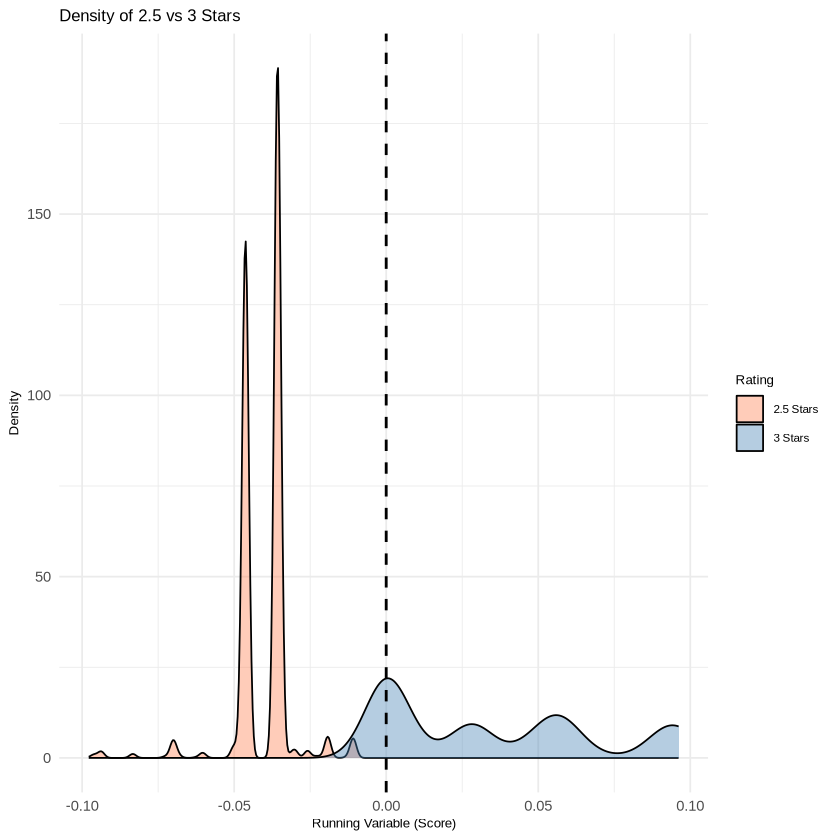

In [21]:
# Assuming 'window1' is the desired condition for filtering
p1 <- ggplot(ma.rd1 %>% filter(window1 == TRUE), 
              aes(x = score, fill = treat)) +
  geom_density(alpha = 0.4) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "black", linewidth = 0.8) +
  scale_fill_manual(values = c("FALSE" = "coral", "TRUE" = "steelblue"),
                    labels = c("2.5 Stars", "3 Stars")) +
  labs(title = "Density of 2.5 vs 3 Stars", x = "Running Variable (Score)",
       y = "Density", fill = "Rating") +
  theme_minimal() +
  theme(plot.title = element_text(size = 10),  # Smaller title
        axis.title = element_text(size = 8),   # Smaller axis titles
        legend.title = element_text(size = 8),  # Smaller legend title
        legend.text = element_text(size = 7))   # Smaller legend text

# Display the plot
print(p1)

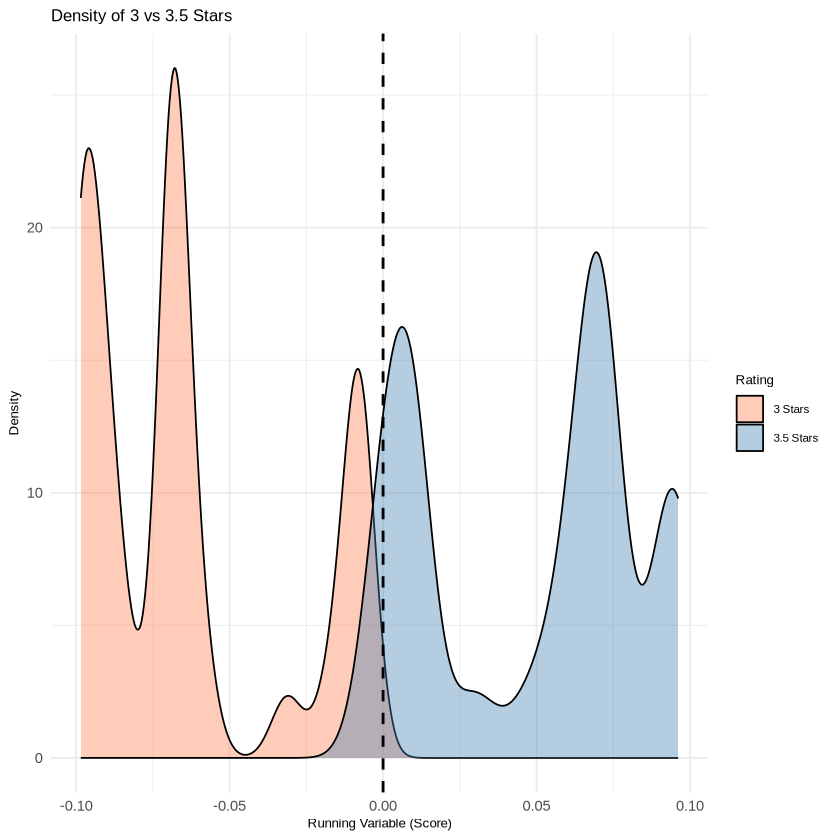

In [23]:
# Assuming 'window1' is the desired condition for filtering
p2 <- ggplot(ma.rd2 %>% filter(window1 == TRUE), 
              aes(x = score, fill = treat)) +
  geom_density(alpha = 0.4) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "black", linewidth = 0.8) +
  scale_fill_manual(values = c("FALSE" = "coral", "TRUE" = "steelblue"),
                    labels = c("3 Stars", "3.5 Stars")) +
  labs(title = "Density of 3 vs 3.5 Stars", x = "Running Variable (Score)",
       y = "Density", fill = "Rating") +
  theme_minimal() +
  theme(plot.title = element_text(size = 10),  # Smaller title
        axis.title = element_text(size = 8),   # Smaller axis titles
        legend.title = element_text(size = 8),  # Smaller legend title
        legend.text = element_text(size = 7))   # Smaller legend text

# Display the plot
print(p2)

We observe a sharp increase in market share in relation to values on either side of the threshold, especially noticeable when comparing 2.5-star to 3-star plans (as seen in the first plot). Specifically, there is a decline from -0.10 to -0.05 in the upper plot, along with a slight rise from 0.05 to 0.10 in the lower plot.

# Question9. 
Examine whether plans just above the threshold values have different characteristics than contracts just below the threshold values. Use HMO and Part D status as your plan characteristics.

In [18]:
summary_df <- data.frame(
  Threshold = c("2.5 vs 3 Stars", "3 vs 3.5 Stars"),
  
  # Part D counts
  PartD_Yes = c(
    sum(ma.rd1 %>% filter(window == TRUE) %>% pull(partd) == "Yes", na.rm = TRUE),
    sum(ma.rd2 %>% filter(window == TRUE) %>% pull(partd) == "Yes", na.rm = TRUE)
  ),
  PartD_No = c(
    sum(ma.rd1 %>% filter(window == TRUE) %>% pull(partd) == "No", na.rm = TRUE),
    sum(ma.rd2 %>% filter(window == TRUE) %>% pull(partd) == "No", na.rm = TRUE)
  ),
  
  # Below/Above threshold
  Below_Threshold = c(
    sum(ma.rd1 %>% filter(window == TRUE) %>% pull(score) < 0, na.rm = TRUE),
    sum(ma.rd2 %>% filter(window == TRUE) %>% pull(score) < 0, na.rm = TRUE)
  ),
  Above_Threshold = c(
    sum(ma.rd1 %>% filter(window == TRUE) %>% pull(score) >= 0, na.rm = TRUE),
    sum(ma.rd2 %>% filter(window == TRUE) %>% pull(score) >= 0, na.rm = TRUE)
  )
)

print(summary_df)

       Threshold PartD_Yes PartD_No Below_Threshold Above_Threshold
1 2.5 vs 3 Stars     12007     9467           19487            1987
2 3 vs 3.5 Stars      4970      675            3212            2433


With a bandwidth of 0.125, we observe that there are significantly more Plan D contracts below the threshold than above, across both categories. Additionally, the number of HMO-approved plans (calculated using the adjusted raw rating, as HMO is defined through Part C) shows considerable variation above and below the threshold. This indicates that there are distinct characteristics among the plans.

# Question10.
Summarize your findings from 5-9. What is the effect of increasing a star rating on enrollments? Briefly explain your results.

# Summary : 
The impact of an increased star rating is directly linked to a higher number of enrollments, especially evident in the upward and downward slopes around the threshold in the Problem 8 plot comparing 2.5-star plans with 3-star plans. However, these findings are highly sensitive to the selected bandwidth (as discussed in Problems 6 and 7), leading to an asymmetric distribution of Plan D contracts above and below the threshold (Problem 9). Additionally, the 3-star ratings undergo the most significant number of round-ups compared to higher-rated plans, making that area particularly volatile for analysis.